In [1]:
import pandas as pd
data=pd.read_excel("cervezas.xlsx")
data.head()

,Unnamed: 0,Name,Calories,Sodium,Alcohol,Cost
0,0,Budweiser,144,15,4.7,0.43
1,1,Schlitz,151,19,4.9,0.43
2,2,Lowenbrau,157,15,0.9,0.48
3,3,Kronenbourg,170,7,5.2,0.73
4,4,Heineken,152,11,5.0,0.77


In [11]:
data

,Unnamed: 0,Name,Calories,Sodium,Alcohol,Cost,Cluster
0,0,Budweiser,144,15,4.7,0.43,1
1,1,Schlitz,151,19,4.9,0.43,1
2,2,Lowenbrau,157,15,0.9,0.48,3
3,3,Kronenbourg,170,7,5.2,0.73,2
4,4,Heineken,152,11,5.0,0.77,2
5,5,Old_Milwaukee,145,23,4.6,0.28,1
6,6,Augsberger,175,24,5.5,0.40,1
7,7,Srohs_Bohemian_Style,149,27,4.7,0.42,1
8,8,Miller_Lite,99,10,4.3,0.43,0
9,9,Budweiser_Light,113,8,3.7,0.40,0


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  20 non-null     int64  
 1   Name        20 non-null     object 
 2   Calories    20 non-null     int64  
 3   Sodium      20 non-null     int64  
 4   Alcohol     20 non-null     float64
 5   Cost        20 non-null     float64
dtypes: float64(2), int64(3), object(1)
memory usage: 1.1+ KB


In [3]:
X=data[['Calories', 'Sodium', 'Alcohol', 'Cost']]
X.head()

,Calories,Sodium,Alcohol,Cost
0,144,15,4.7,0.43
1,151,19,4.9,0.43
2,157,15,0.9,0.48
3,170,7,5.2,0.73
4,152,11,5.0,0.77


In [4]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_scaled

array([[ 0.38791334,  0.00779468,  0.43380786, -0.45682969],
       [ 0.6250656 ,  0.63136906,  0.62241997, -0.45682969],
       [ 0.82833896,  0.00779468, -3.14982226, -0.10269815],
       [ 1.26876459, -1.23935408,  0.90533814,  1.66795955],
       [ 0.65894449, -0.6157797 ,  0.71672602,  1.95126478],
       [ 0.42179223,  1.25494344,  0.3395018 , -1.5192243 ],
       [ 1.43815906,  1.41083704,  1.1882563 , -0.66930861],
       [ 0.55730781,  1.87851782,  0.43380786, -0.52765599],
       [-1.1366369 , -0.7716733 ,  0.05658363, -0.45682969],
       [-0.66233238, -1.08346049, -0.5092527 , -0.66930861],
       [ 0.25239776,  0.47547547,  0.3395018 , -0.38600338],
       [-1.03500022,  0.00779468, -0.13202848, -0.24435076],
       [ 0.08300329, -0.6157797 , -0.03772242,  0.03895447],
       [ 0.59118671,  0.63136906,  0.43380786,  1.88043848],
       [ 0.55730781, -1.39524768,  0.71672602,  2.0929174 ],
       [-2.18688263,  0.00779468, -1.82953748, -0.81096123],
       [ 0.21851887,  0.

# Algoritmo Jerárquico. Aglomerativo

In [6]:
from sklearn.cluster import AgglomerativeClustering
modelo=AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
modelo.fit(X_scaled)

AgglomerativeClustering(n_clusters=4)

In [36]:
clusters=modelo.labels_
clusters

array([1, 1, 3, 2, 2, 1, 1, 1, 0, 0, 1, 0, 0, 2, 2, 0, 1, 1, 0, 0])

In [39]:
import numpy as np
print(len(np.unique(clusters)))

4


In [8]:
data['Cluster']=clusters
print(data.head())

   Unnamed: 0         Name  Calories  Sodium  Alcohol  Cost  Cluster
0           0    Budweiser       144      15      4.7  0.43        1
1           1      Schlitz       151      19      4.9  0.43        1
2           2    Lowenbrau       157      15      0.9  0.48        3
3           3  Kronenbourg       170       7      5.2  0.73        2
4           4     Heineken       152      11      5.0  0.77        2


In [40]:
cluster_size=data.groupby('Cluster').size()
print(cluster_size)

Cluster
0    7
1    8
2    4
3    1
dtype: int64


In [43]:
cluster_percent = data["Cluster"].value_counts(normalize=True) * 100
print(cluster_percent)

Cluster
1    40.0
0    35.0
2    20.0
3     5.0
Name: proportion, dtype: float64


In [49]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  20 non-null     int64  
 1   Name        20 non-null     object 
 2   Calories    20 non-null     int64  
 3   Sodium      20 non-null     int64  
 4   Alcohol     20 non-null     float64
 5   Cost        20 non-null     float64
 6   Cluster     20 non-null     int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 1.2+ KB


In [50]:
cluster_profiling=data[['Calories', 'Sodium', 'Alcohol', 'Cost','Cluster']].groupby('Cluster').mean()
cluster_profiling

,Calories,Sodium,Alcohol,Cost
Cluster,,,,
0,98.000,10.285714,3.671429,0.442857
1,148.375,21.125000,4.787500,0.407500
2,155.250,10.750000,4.975000,0.762500
3,157.000,15.000000,0.900000,0.480000


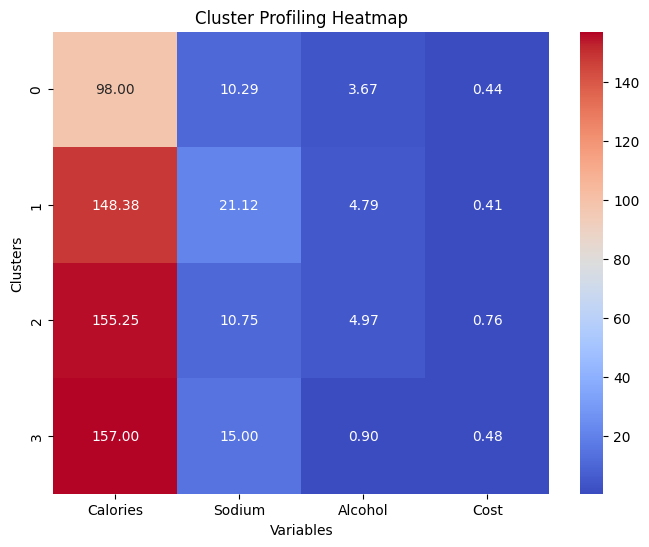

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    cluster_profiling,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Cluster Profiling Heatmap")
plt.xlabel("Variables")
plt.ylabel("Clusters")

plt.show()

**interpretación de perfiles**
1. Cluster 0 Cervezas ligeras
- bajas calorias
- bajo sodio
- alcohol moderado
- costo bajo

2. Cluster 1 cervezas estándar
- calorias medias
- sodio alto
- alcohol moderado
- costo bajo

3. Cluster 2 cervezas premium
- calorias altas
- sodio bajo
- alcohol alto
- costo alto

4. Cluster 3 cervezas sin alcohol
- calorias altas
- sodio moderados
- alcohol muy bajo
- costo moderado

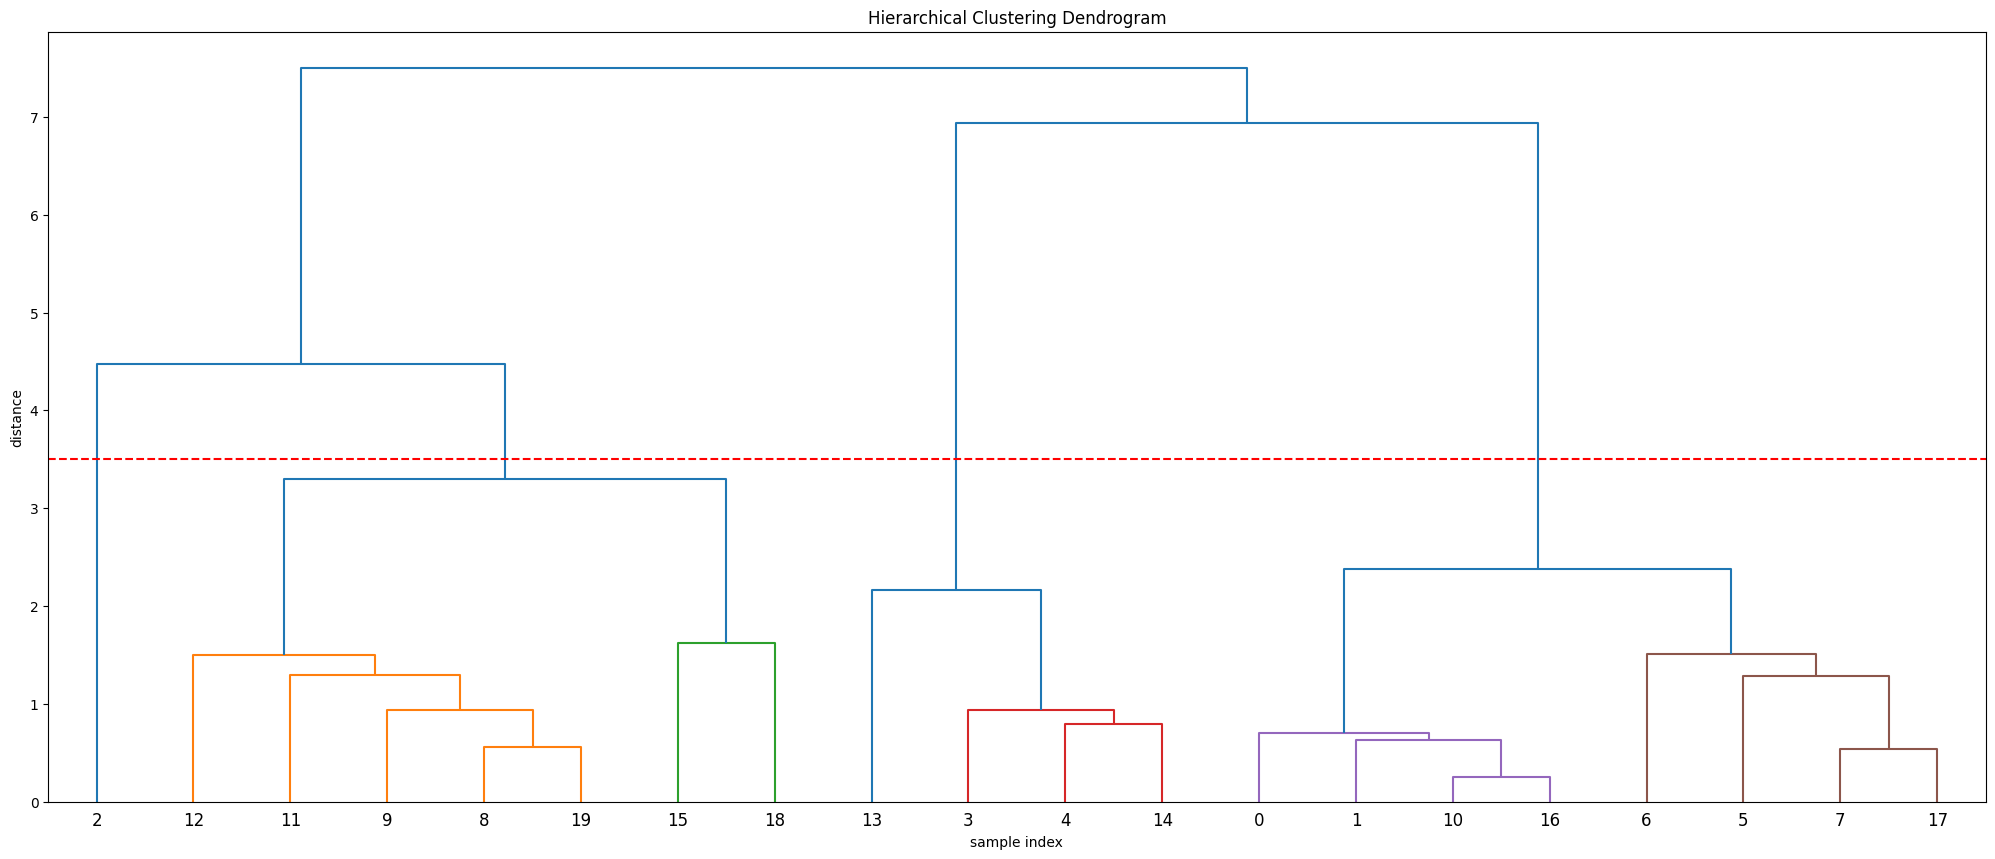

In [34]:
from scipy.cluster.hierarchy import dendrogram,linkage
import matplotlib.pyplot as plt
Z=linkage(X_scaled, method='ward')
fig = plt.figure(figsize=(25, 10))
dendrogram(Z,truncate_mode='lastp', p=20,color_threshold=2)
#linea de corte
plt.axhline(y=3.5, color='r', linestyle='--')
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('sample index')
plt.ylabel('distance')

plt.show()


In [17]:
from scipy.cluster.hierarchy import fcluster

clusters = fcluster(Z, t=4, criterion='distance')


In [52]:
from sklearn.metrics import silhouette_score

for k in range(2,8):
    model = AgglomerativeClustering(n_clusters=k)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(k, score)
#

2 0.31823936817062226
3 0.45777415910909475
4 0.47546412252215964
5 0.44406582701642483
6 0.3653901114020658
7 0.3390763170371786


coef. silhouette mide que tan bien separados y compactos están los clusters. Rango -1 a 1
| Valor          | Interpretación                 |
| -------------- | ------------------------------ |
| **> 0.7**      | clusters muy bien definidos    |
| **0.5 – 0.7**  | buena separación               |
| **0.25 – 0.5** | estructura moderada            |
| **< 0.25**     | clusters débiles o poco claros |
| **< 0**        | mala asignación de clusters    |


**interpretación:** En estos resultados el mejor numero de clusters es 4 porque encontramos el valor máximo de coef. silhouette 0.475 que nos indica estructura moderada